In [1]:
import numpy as np
import matplotlib.pyplot as plt
n1 = 100  # x方向要素数
n2 = 100  # y方向要素数
L1 = 1.0  # x方向長さ
L2 = 1.0  # y方向長さ
h = L1/n1 # 要素長
k = 1.0   # 熱伝導率
Q = 2.0   # 熱源
Ke = 1/6*np.array([ # 要素熱伝導行列/k
    [ 4, -1, -2, -1],
    [-1, 4, -1, -2],
    [-2, -1, 4, -1],
    [-1, -2, -1, 4]]) 

In [2]:
ind_node = np.arange((n1+1)*(n2+1)).reshape(n2+1, n1+1) # 節点番号
ind_elem = ind_node[:-1, :-1].ravel() # 要素番号
ind_edge = ind_elem[:, None] + np.array([0, 1, n1+2, n1+1]) # 全体の局所節点番号

In [3]:
from scipy import sparse
sK = sK = (Ke.flatten()[:, None]*k*np.ones(n1*n2)).flatten('F')
iK = np.repeat(ind_edge, 4, axis=0).flatten()
jK = np.repeat(ind_edge, 4, axis=1).flatten()
K = sparse.coo_matrix((sK, (iK, jK))).tocsc()

In [4]:
ind_fixed = n1//2 # ディリクレ境界条件(1節点のみ)
free = np.setdiff1d(np.arange((n1+1)*(n2+1)), ind_fixed) # 自由な節点
ind_bound = np.concatenate([ # 全境界
    np.arange(1, n1+1), 
    np.arange(2*(n1+1)-1, (n1+1)*(n2+1), n1+1),
    np.arange((n1+1)*n2+1, (n1+1)*(n2+1)-1), 
    np.arange(0, (n1+1)*(n2+1), n1+1)])
ind_inside = np.setdiff1d(np.arange((n1+1)*(n2+1)), ind_bound) # 領域内部
ind_bound_adiabatic = np.setdiff1d(ind_bound, ind_fixed) # 断熱境界
ind_bound_except_corners = np.setdiff1d(ind_bound, 
                                        [0, n1, n2*(n1+1), (n1+1)*(n2+1)-1]) # 四隅を除く境界

In [5]:
f = np.zeros((n1+1)*(n2+1))
f[ind_inside] += h**2*Q # 領域内部の熱源の足し合わせ
f[ind_bound_adiabatic] += h**2*Q/4 # ノイマン境界上での熱源の足し合わせ
f[ind_bound_except_corners] += h**2*Q/4 # 四隅を除く境界上での熱源の重ね合わせ

In [6]:
from scipy.sparse import linalg as spla
d = np.zeros((n1+1)*(n2+1))
ind_free = np.setdiff1d(np.arange((n1+1)*(n2+1)), ind_fixed) # 計算対象節点
d[ind_free] = spla.spsolve(K[ind_free][:, ind_free], f[ind_free])

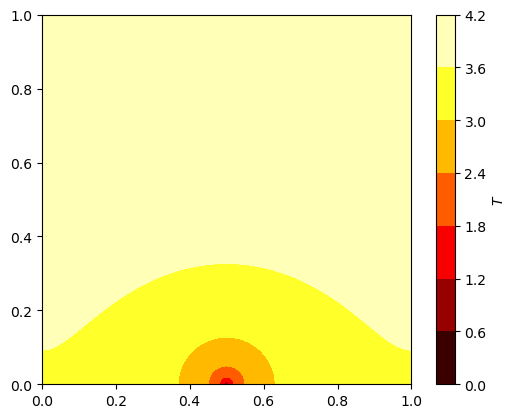

In [7]:
x_p, y_p = np.linspace(0, L1, n1+1), np.linspace(0, L2, n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, d.reshape((n2+1, n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')

In [8]:
from scipy import sparse
k0 = 0.001*k # 設計変数がゼロにおける熱伝導率
p = 3.0      # ペナルティパラメータ
x = np.full(n1*n2, 0.3) # 設計変数(すべての要素で0.3に設定)
iK = np.repeat(ind_edge, 4, axis=0).flatten()
jK = np.repeat(ind_edge, 4, axis=1).flatten()
sK = (Ke.flatten()[:, None]*(k0+(k-k0)*x**p)).flatten('F')
K = sparse.coo_matrix((sK, (iK, jK))).tocsc()

In [9]:
from scipy.sparse import linalg as spla
d = np.zeros((n1+1)*(n2+1))
ind_free = np.setdiff1d(np.arange((n1+1)*(n2+1)), ind_fixed) # 計算対象節点
d[ind_free] = spla.spsolve(K[ind_free][:, ind_free], f[ind_free])

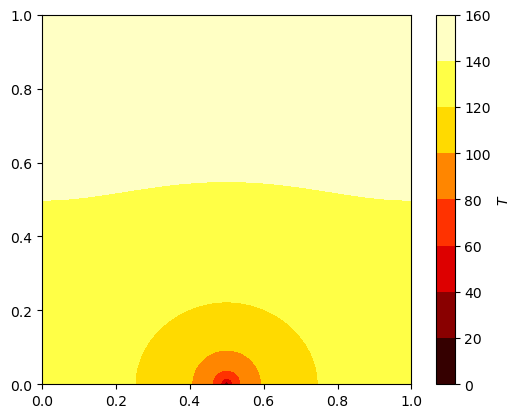

In [10]:
x_p, y_p = np.linspace(0, L1, n1+1), np.linspace(0, L2, n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, d.reshape((n2+1, n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')

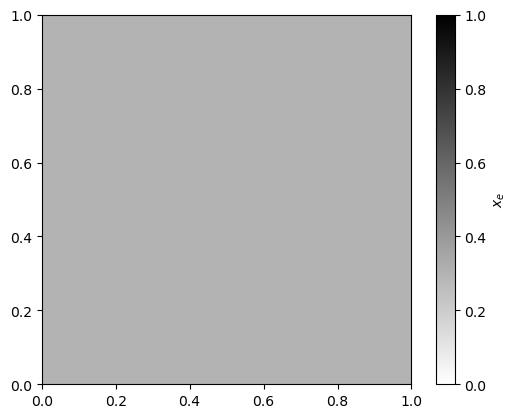

In [11]:
x_p, y_p = np.linspace(0, L1, n1), np.linspace(0, L2, n2)
plt.imshow(x.reshape((n2, n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label='$x_e$')

In [12]:
f_TC = np.dot(f, d)
print(f_TC)

272.22130942915635


In [13]:
x_p, y_p = np.meshgrid(np.linspace(0, L1, n1+1), 
                       np.linspace(0, L2, n2+1)) # 一旦x-y座標系に変換    
c1x, c1y, c2x, c2y = 0.3, 0.3, 0.7, 0.7 # 部分領域の中心座標
rc = 0.3 # 部分領域の半径
ind_obj_d1 = (np.sqrt((x_p-c1x)**2+(y_p-c1y)**2)<rc).flatten() # 部分領域1
ind_obj_d2 = (np.sqrt((x_p-c2x)**2+(y_p-c2y)**2)<rc).flatten() # 部分領域2
ind_obj_domain = ind_obj_d1 | ind_obj_d2 # 全部分領域
f_obj = np.zeros((n1+1)*(n2+1))
f_obj[ind_obj_domain] = h**2 # 部分領域の節点に対応する成分にh^2を設定
f_T = np.dot(f_obj, d) # 目的関数の計算
print(f_T)

76.03435391961715
